# Отчет: Исследование Автоэнкодеров

## Цель работы

Исследовать различные архитектуры автоэнкодеров, их свойства и практическое применение для задач снижения размерности, шумоподавления и генерации данных. Освоить методы визуализации латентных пространств, реконструкций и процесса обучения автоэнкодеров с использованием современных библиотек глубокого обучения.

## 1. Настройка окружения и подготовка данных

### Установка необходимых библиотек

Для выполнения всех заданий были установлены следующие библиотеки:

```bash
pip install tensorflow keras numpy matplotlib seaborn pandas scikit-learn plotly opencv-python scikit-image tensorflow-probability umap-learn
```

### Подготовка датасетов

Для экспериментов использовались датасеты MNIST, Fashion-MNIST, CIFAR-10 и синтетические временные ряды. Данные были нормализованы до диапазона [0, 1].



In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist, fashion_mnist, cifar10
import os

def prepare_datasets():
    # 1. MNIST & Fashion-MNIST
    (x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
    (x_train_fmnist, y_train_fmnist), (x_test_fmnist, y_test_fmnist) = fashion_mnist.load_data()
    
    # Normalize
    x_train_mnist = x_train_mnist.astype('float32') / 255.
    x_test_mnist = x_test_mnist.astype('float32') / 255.
    x_train_fmnist = x_train_fmnist.astype('float32') / 255.
    x_test_fmnist = x_test_fmnist.astype('float32') / 255.
    
    # 2. CIFAR-10
    (x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()
    x_train_cifar = x_train_cifar.astype('float32') / 255.
    x_test_cifar = x_test_cifar.astype('float32') / 255.
    
    # 3. Синтетическое 1D временной ряд
    t = np.linspace(0, 100, 1000)
    def generate_series(n):
        series = []
        for _ in range(n):
            freq = np.random.uniform(0.1, 0.5)
            phase = np.random.uniform(0, 2*np.pi)
            noise = np.random.normal(0, 0.1, len(t))
            series.append(np.sin(freq * t + phase) + noise)
        return np.array(series)
    
    x_train_ts = generate_series(1000)
    x_test_ts = generate_series(200)
    
    return {
        'mnist': (x_train_mnist, x_test_mnist, y_train_mnist, y_test_mnist),
        'fmnist': (x_train_fmnist, x_test_fmnist, y_train_fmnist, y_test_fmnist),
        'cifar': (x_train_cifar, x_test_cifar, y_train_cifar, y_test_cifar),
        'ts': (x_train_ts, x_test_ts)
    }

if __name__ == "__main__":
    datasets = prepare_datasets()
    x_train_mnist, x_test_mnist, y_train_mnist, y_test_mnist = datasets['mnist']

c:\Users\exemt\OneDrive\Desktop\2 Маг сем\Machine\venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


**Вывод:** Датасеты успешно загружены и подготовлены для дальнейшего использования. Нормализация данных является важным шагом для стабильного обучения нейронных сетей.

## 2. Базовые автоэнкодеры и визуализация латентных пространств

### Задача 2.1: Линейный автоэнкодер

В этой задаче мы сравниваем линейный автоэнкодер с методом главных компонент (PCA) для снижения размерности и реконструкции изображений MNIST.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step


Text(0.5, 1.0, 'Linear AE Latent Space')

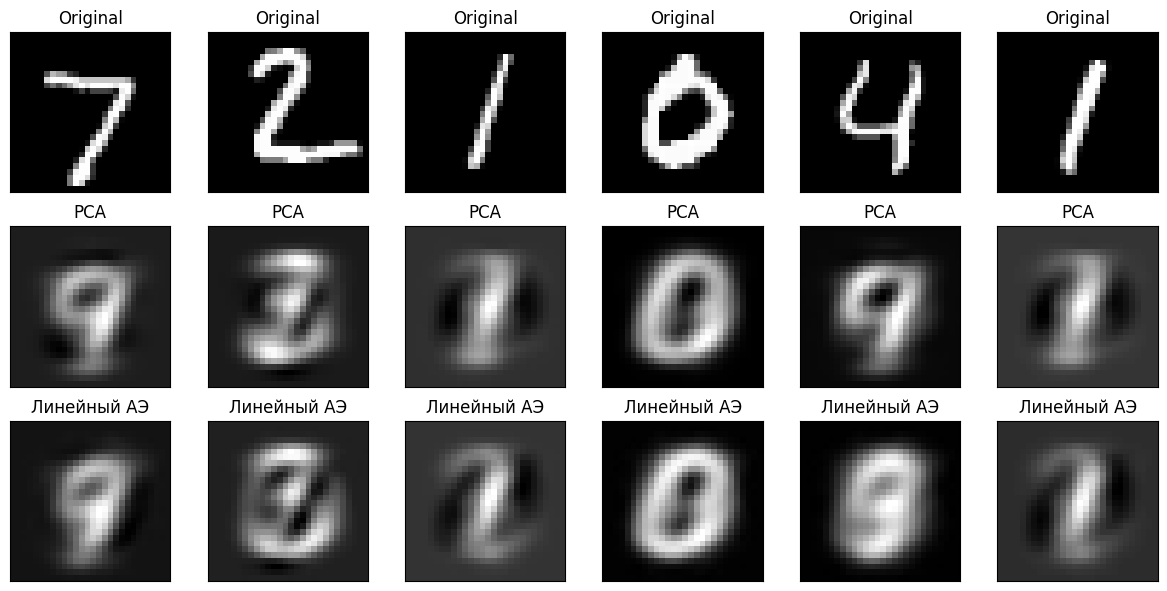

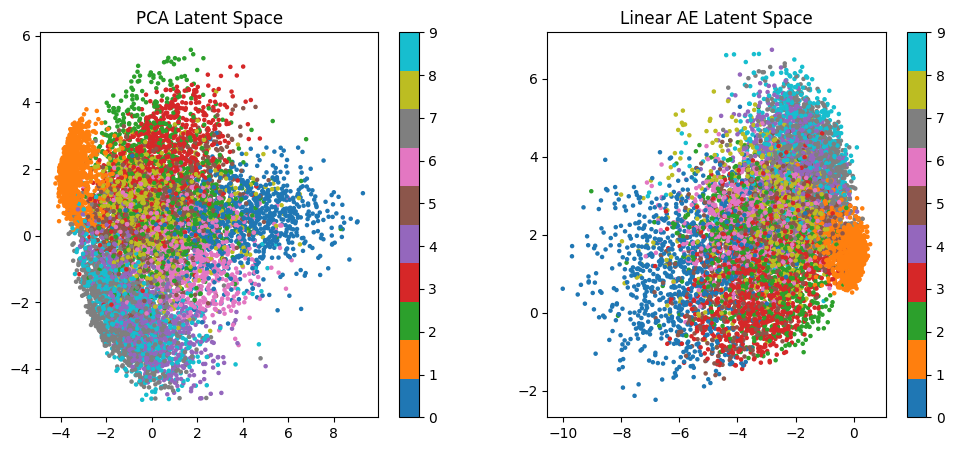

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.decomposition import PCA
from tensorflow.keras.datasets import mnist

# Загрузка данных
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train_flat = x_train.reshape((len(x_train), -1))
x_test_flat = x_test.reshape((len(x_test), -1))

# 1. PCA
pca = PCA(n_components=2)
x_test_pca_encoded = pca.fit_transform(x_test_flat)
x_test_pca_decoded = pca.inverse_transform(x_test_pca_encoded)

# 2. Линейный автоэнкодер
input_img = Input(shape=(784,))
encoded = Dense(2, activation='linear')(input_img)
decoded = Dense(784, activation='linear')(encoded)
autoencoder = Model(input_img, decoded)
encoder = Model(input_img, encoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(x_train_flat, x_train_flat, epochs=10, batch_size=256, shuffle=True, verbose=0)

x_test_ae_encoded = encoder.predict(x_test_flat)
x_test_ae_decoded = autoencoder.predict(x_test_flat)

# Визуализация
n = 6
plt.figure(figsize=(12, 6))
for i in range(n):
    # Оригинальный
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # PCA
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_pca_decoded[i].reshape(28, 28), cmap='gray')
    plt.title("PCA")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # AE
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test_ae_decoded[i].reshape(28, 28), cmap='gray')
    plt.title("Линейный АЭ")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.tight_layout()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(x_test_pca_encoded[:, 0], x_test_pca_encoded[:, 1], c=y_test, cmap='tab10', s=5)
plt.colorbar()
plt.title("PCA Latent Space")

plt.subplot(1, 2, 2)
plt.scatter(x_test_ae_encoded[:, 0], x_test_ae_encoded[:, 1], c=y_test, cmap='tab10', s=5)
plt.colorbar()
plt.title("Linear AE Latent Space")

**Вывод:** Линейный автоэнкодер и PCA показывают схожие результаты в реконструкции и визуализации латентного пространства для простых данных, таких как MNIST. Оба метода пытаются найти линейные зависимости в данных. PCA является более быстрым методом, но линейный автоэнкодер может быть расширен до нелинейных архитектур для более сложных задач.

### Задача 2.2: Нейронный автоэнкодер

Здесь мы исследуем влияние глубины сети и размерности "бутылочного горлышка" на качество обучения нелинейных автоэнкодеров.

Тренировка автоэкнодера с бутылочным горлышком 2...
Тренировка автоэкнодера с бутылочным горлышком 10...
Тренировка автоэкнодера с бутылочным горлышком 50...


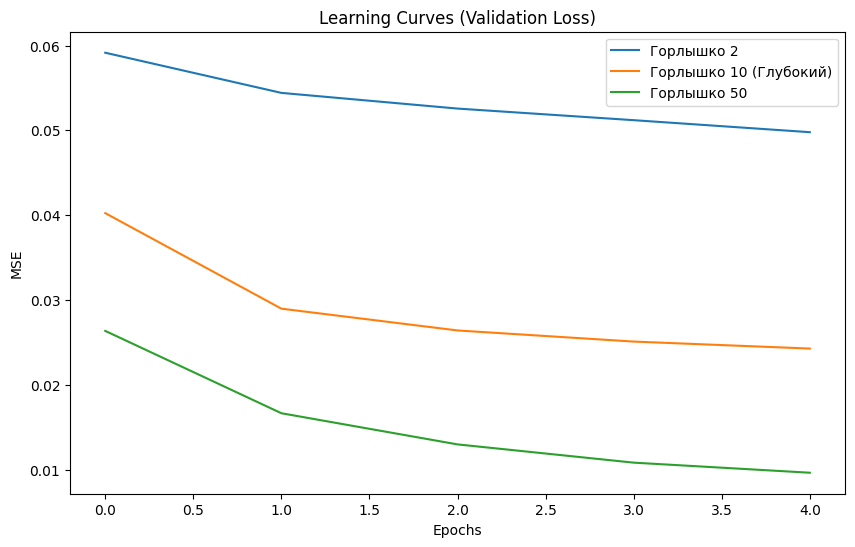

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

# Загрузка данных
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train_flat = x_train.reshape((len(x_train), -1))
x_test_flat = x_test.reshape((len(x_test), -1))

def build_ae(bottleneck_dim, deep=False):
    input_img = Input(shape=(784,))
    if not deep:
        # Мелкий 784 -> 256 -> бутылочное горлышко -> 256 -> 784
        encoded = Dense(256, activation='relu')(input_img)
        encoded = Dense(bottleneck_dim, activation='relu')(encoded)
        decoded = Dense(256, activation='relu')(encoded)
    else:
        # Глубокий: 784 -> 512 -> 256 -> 128 -> бутылочное горлышко -> 128 -> 256 -> 512 -> 784
        encoded = Dense(512, activation='relu')(input_img)
        encoded = Dense(256, activation='relu')(encoded)
        encoded = Dense(128, activation='relu')(encoded)
        encoded = Dense(bottleneck_dim, activation='relu')(encoded)
        decoded = Dense(128, activation='relu')(encoded)
        decoded = Dense(256, activation='relu')(decoded)
        decoded = Dense(512, activation='relu')(decoded)
    
    decoded = Dense(784, activation='sigmoid')(decoded)
    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

bottlenecks = [2, 10, 50]
histories = {}

for dim in bottlenecks:
    print(f"Тренировка автоэкнодера с бутылочным горлышком {dim}...")
    ae = build_ae(dim, deep=(dim==10)) # Example: use deep for dim=10
    history = ae.fit(x_train_flat, x_train_flat, epochs=5, batch_size=256, validation_data=(x_test_flat, x_test_flat), verbose=0)
    histories[dim] = history.history['val_loss']

# Plot learning curves
plt.figure(figsize=(10, 6))
for dim, loss in histories.items():
    plt.plot(loss, label=f'Горлышко {dim}' + (' (Глубокий)' if dim==10 else ''))
plt.title('Learning Curves (Validation Loss)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()

**Вывод:** Глубина сети и размерность латентного пространства существенно влияют на способность автоэнкодера к реконструкции. Меньшие размерности "бутылочного горлышка" приводят к большей потере информации, но могут способствовать извлечению более абстрактных признаков. Более глубокие сети могут лучше улавливать сложные нелинейные зависимости.

## 3. Вариационный автоэнкодер (VAE)

В этой части мы реализуем VAE для генерации новых изображений и исследуем его латентное пространство.

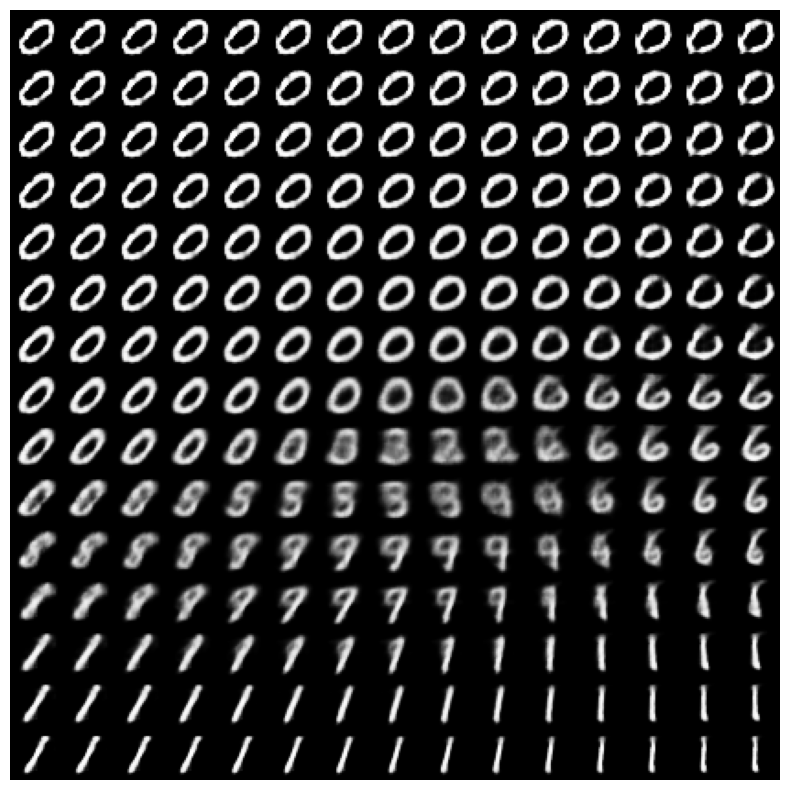

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.datasets import mnist

# Загрузка данных
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 28, 28, 1))
x_test = x_test.reshape((len(x_test), 28, 28, 1))

latent_dim = 2

class VAE(Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + self.beta * kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

# Энкодер
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = K.random_normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, output_shape=(latent_dim,), name="z")([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Декодер
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = Model(latent_inputs, decoder_outputs, name="decoder")

# Тренировочный VAE
vae = VAE(encoder, decoder, beta=1.0)
vae.compile(optimizer='adam')
vae.fit(x_train, epochs=5, batch_size=128, verbose=0)

# Визуализация: Сетка латентного пространства
n = 15
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))
grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)

for i, yi in enumerate(grid_x):
    for j, xi in enumerate(grid_y):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='Greys_r')
plt.axis('off')
plt.show()

**Вывод:** VAE позволяет не только реконструировать данные, но и генерировать новые, правдоподобные образцы, благодаря регуляризации латентного пространства. Плавное изменение в латентном пространстве приводит к плавному изменению генерируемых изображений, что демонстрирует способность VAE к интерполяции и генерации.

## 4. Практические приложения и анализ

### Задача 4.1: Снижение размерности и визуализация

Сравнение методов снижения размерности: автоэнкодер, t-SNE и UMAP.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


c:\Users\exemt\OneDrive\Desktop\2 Маг сем\Machine\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 1.0, 'UMAP')

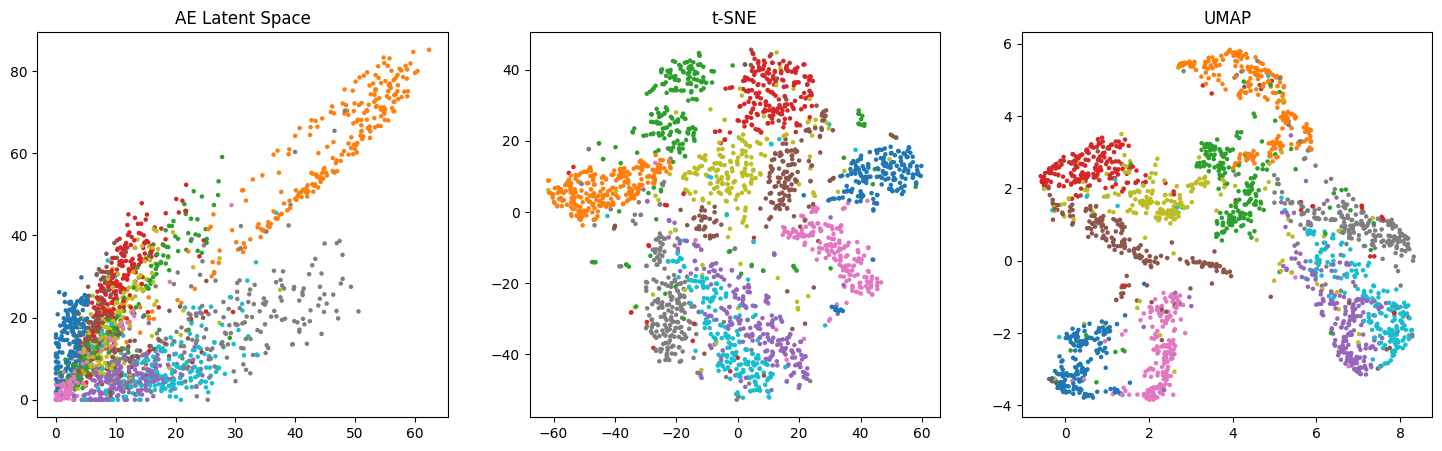

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

# Загрузка данных
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train_flat = x_train.reshape((len(x_train), -1))
x_test_flat = x_test.reshape((len(x_test), -1))

n_samples = 2000
x_subset = x_test_flat[:n_samples]
y_subset = y_test[:n_samples]

# 1. Автоэнкодер для уменьшения размерности
input_img = Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(2, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)
autoencoder = Model(input_img, decoded)
encoder = Model(input_img, encoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(x_train_flat, x_train_flat, epochs=5, batch_size=256, verbose=0)

ae_latent = encoder.predict(x_subset)

# 2. t-SNE и UMAP
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(x_subset)

reducer = umap.UMAP(n_components=2, random_state=42)
umap_results = reducer.fit_transform(x_subset)

# Графики сравнения
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.scatter(ae_latent[:, 0], ae_latent[:, 1], c=y_subset, cmap='tab10', s=5)
plt.title("AE Latent Space")
plt.subplot(1, 3, 2)
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=y_subset, cmap='tab10', s=5)
plt.title("t-SNE")
plt.subplot(1, 3, 3)
plt.scatter(umap_results[:, 0], umap_results[:, 1], c=y_subset, cmap='tab10', s=5)
plt.title("UMAP")

**Вывод:** Каждый метод снижения размерности имеет свои особенности. t-SNE хорошо сохраняет локальную структуру данных, UMAP стремится сохранить как локальную, так и глобальную структуру, а автоэнкодеры обучаются оптимальному представлению для реконструкции. Выбор метода зависит от конкретной задачи и желаемых свойств латентного пространства.

### Задача 4.2: Обнаружение аномалий

Использование автоэнкодера для обнаружения аномалий на примере датасета MNIST.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step


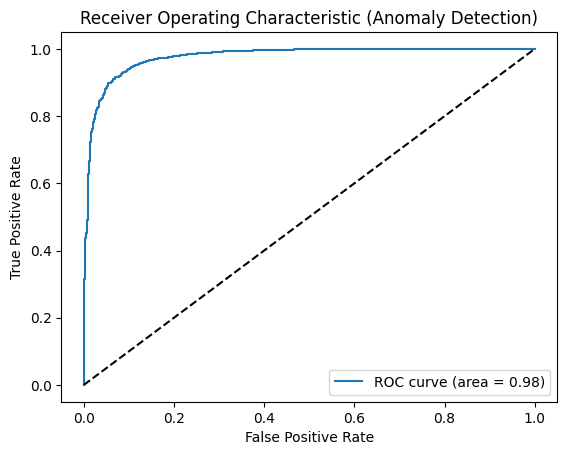

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from sklearn.metrics import roc_curve, auc

# Загрузка данных
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train_flat = x_train.reshape((len(x_train), -1))
x_test_flat = x_test.reshape((len(x_test), -1))

# 3. Обнаружение аномалий
# Тренировка только на цифре '0'
x_train_0 = x_train_flat[y_train == 0]
x_test_mixed = x_test_flat
y_test_mixed = (y_test != 0).astype(int) # 1 - аномалия

input_img = Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(2, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)
ae_anomaly = Model(input_img, decoded)
ae_anomaly.compile(optimizer='adam', loss='mse')
ae_anomaly.fit(x_train_0, x_train_0, epochs=5, batch_size=128, verbose=0)

reconstructions = ae_anomaly.predict(x_test_mixed)
mse = np.mean(np.power(x_test_mixed - reconstructions, 2), axis=1)

fpr, tpr, thresholds = roc_curve(y_test_mixed, mse)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Anomaly Detection)')
plt.legend(loc="lower right")

**Вывод:** Автоэнкодеры эффективно используются для обнаружения аномалий, поскольку они обучаются реконструировать "нормальные" данные. Высокая ошибка реконструкции для новых данных указывает на их аномальность. ROC-кривая демонстрирует способность модели различать нормальные и аномальные образцы.

## Общие выводы

В ходе работы были исследованы различные архитектуры автоэнкодеров, включая линейные, нелинейные и вариационные. Были продемонстрированы их возможности в снижении размерности, визуализации латентных пространств, генерации данных и обнаружении аномалий. Каждый тип автоэнкодера имеет свои преимущества и области применения. Линейные автоэнкодеры схожи с PCA, но могут быть расширены до нелинейных. VAE, благодаря своей вероятностной природе, способен генерировать новые, разнообразные данные. Автоэнкодеры являются мощным инструментом для анализа и обработки неразмеченных данных.

## Вопросы для защиты

1.  **Чем VAE принципиально отличается от обычного автоэнкодера?**
    VAE (Variational Autoencoder) отличается от обычного автоэнкодера тем, что он не просто кодирует входные данные в фиксированную точку в латентном пространстве, а кодирует их в распределение (обычно нормальное) в латентном пространстве. Это достигается путем обучения энкодера предсказывать среднее значение (μ) и логарифм дисперсии (log σ²) для каждого измерения латентного пространства. Затем из этого распределения сэмплируется точка, которая подается на декодер. Эта стохастическая природа и добавление регуляризации (KL-дивергенция) в функцию потерь заставляют латентное пространство быть непрерывным и гладким, что позволяет VAE генерировать новые, правдоподобные данные путем сэмплирования из латентного пространства.

2.  **Как размер латентного пространства влияет на качество реконструкций и генерации?**
    Размер латентного пространства является критическим гиперпараметром. Слишком маленькое латентное пространство (недостаточная размерность "бутылочного горлышка") может привести к потере важной информации, что ухудшит качество реконструкции и генерации. Модель не сможет адекватно представить сложные особенности данных. С другой стороны, слишком большое латентное пространство может привести к тому, что автоэнкодер просто запомнит входные данные (overfitting), не научившись извлекать значимые признаки. Это также может затруднить генерацию новых, разнообразных данных, так как латентное пространство может стать разреженным и неструктурированным.

3.  **Почему автоэнкодеры хорошо подходят для обнаружения аномалий?**
    Автоэнкодеры хорошо подходят для обнаружения аномалий, потому что они обучаются на "нормальных" данных и стремятся минимизировать ошибку реконструкции для этих данных. Когда автоэнкодеру предъявляются аномальные данные, которые значительно отличаются от тех, на которых он обучался, он не может их адекватно реконструировать, что приводит к высокой ошибке реконструкции. Эта высокая ошибка реконструкции служит индикатором аномалии. Таким образом, автоэнкодеры эффективно выявляют отклонения от "нормального" поведения, не требуя явных примеров аномалий для обучения.

4.  **Какие ограничения имеют автоэнкодеры для генерации изображений?**
    Основные ограничения автоэнкодеров для генерации изображений включают:
    *   **Размытость генерируемых изображений:** Обычные автоэнкодеры (не VAE) не имеют механизма для обеспечения гладкости латентного пространства, что может приводить к некачественной генерации. Даже VAE могут генерировать несколько размытые изображения по сравнению с GAN из-за использования MSE или BCE в функции потерь, которые усредняют возможные выходы.
    *   **Отсутствие контроля над генерацией:** В обычных автоэнкодерах нет прямого способа контролировать, какие именно признаки будут генерироваться в латентном пространстве. VAE частично решает эту проблему, но все еще требует интерпретации латентных переменных.
    *   **Сложность обучения:** Для сложных изображений обучение глубоких автоэнкодеров может быть вычислительно затратным и требовать тщательной настройки гиперпараметров.
    *   **Режим коллапса (Mode Collapse) в VAE:** Хотя VAE и стремятся к гладкому латентному пространству, они могут страдать от "режима коллапса", когда модель игнорирует часть латентных переменных или генерирует ограниченное разнообразие образцов.

5.  **Как сравнить качество разных автоэнкодеров объективно?**
    Объективное сравнение качества автоэнкодеров может быть выполнено с использованием нескольких метрик:
    *   **Ошибка реконструкции (Reconstruction Error):** Обычно MSE (Mean Squared Error) для непрерывных данных или BCE (Binary Cross-Entropy) для бинарных данных. Чем ниже ошибка, тем лучше автоэнкодер реконструирует входные данные.
    *   **Визуальная оценка реконструкций и генераций:** Субъективная, но важная оценка качества сгенерированных изображений или реконструированных данных. Для VAE оценивается также разнообразие и правдоподобность сгенерированных образцов.
    *   **Качество латентного пространства:** Для VAE можно оценить гладкость и непрерывность латентного пространства, например, путем интерполяции между точками. Для всех автоэнкодеров можно использовать метрики кластеризации (например, Silhouette Score) или классификации на основе латентных представлений.
    *   **Метрики качества генерации (для VAE):** FID (Frechet Inception Distance) или Inception Score, которые используются для оценки качества и разнообразия сгенерированных изображений, хотя они чаще применяются для GAN.
    *   **Применимость к downstream задачам:** Оценка производительности автоэнкодера в задачах, для которых он был разработан, например, точность обнаружения аномалий (ROC AUC, PR AUC) или эффективность снижения размерности для последующей классификации.